# tap.vco~ — virtual-analog oscillator verification

`tap.vco~` is the repo's source-side virtual-analog oscillator: polyBLEP
alias-suppressed saw and pulse, triangle by leaky integration of the BLEP square,
pure sine — all on one master phase, morphed by a continuous **shape** parameter
(0 sine → 1 tri → 2 saw → 3 pulse). On top: hard sync with sub-sample reset,
through-zero linear FM calibrated in Hz, and a deterministic per-seed analog drift
section.

This notebook machine-checks those claims against the **actual C++ kernel**
(`include/taptools/vco.h`) through the C ABI.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = tap.PALETTE
fs = 48000


def spectrum_db(y, sr=fs):
    """Hann-windowed magnitude spectrum in dBFS-ish units."""
    n = len(y)
    w = np.hanning(n)
    Y = np.abs(np.fft.rfft(y * w)) / (np.sum(w) / 2)
    return np.fft.rfftfreq(n, 1 / sr), 20 * np.log10(Y + 1e-12)


def db_at(freqs, db, hz):
    return float(np.interp(hz, freqs, db))


def peak_freq(y, sr=fs, fmin=20.0):
    """Dominant frequency via parabolic interpolation on the windowed FFT peak."""
    freqs, db = spectrum_db(y, sr)
    sel = freqs >= fmin
    i = np.argmax(db[sel]) + np.searchsorted(freqs, fmin)
    if 0 < i < len(db) - 1:
        a, b, c = db[i - 1], db[i], db[i + 1]
        d = 0.5 * (a - c) / (a - 2 * b + c + 1e-30)
    else:
        d = 0.0
    return float((i + d) * sr / len(y))


## 1. The four waveforms, and tuning accuracy

The shape parameter's integer corners are the pure waveforms. Tuning must be exact:
we measure the fundamental of a 440 Hz saw from the interpolated FFT peak and
express the error in cents.

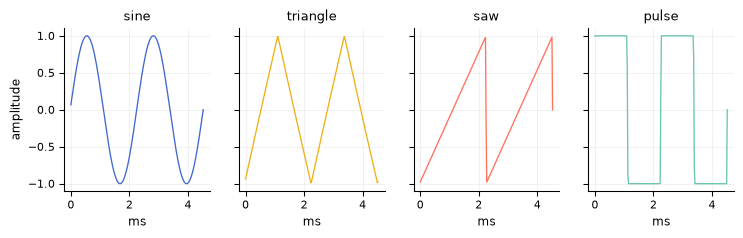

440 Hz saw measures 440.00 Hz (-0.00 cents)


In [2]:
names = ["sine", "triangle", "saw", "pulse"]
fig, axes = plt.subplots(1, 4, figsize=(9, 2.2), sharey=True)
for i, ax in enumerate(axes):
    o = tap.Vco(fs, frequency=440, shape=i)
    y = o.process(fs // 4)
    cyc = int(2 * fs / 440)
    ax.plot(np.arange(cyc) / fs * 1000, y[-cyc:], color=PAL[i], lw=1.0)
    ax.set(title=names[i], xlabel="ms")
axes[0].set_ylabel("amplitude")
plt.show()

o = tap.Vco(fs, frequency=440, shape=tap.Vco.SAW)
y = o.process(2 * fs)[fs:]
f0 = peak_freq(y)
cents = 1200 * np.log2(f0 / 440)
print(f"440 Hz saw measures {f0:.2f} Hz ({cents:+.2f} cents)")
assert abs(cents) < 5

## 2. polyBLEP alias suppression — the virtual-analog proof

A naive (trivially sampled) saw at 3951 Hz (B7) folds its harmonics above Nyquist
back into the audible band. The 13th harmonic (51.4 kHz) aliases to ~3.36 kHz —
right in the mids. The kernel's Catch suite pins > 35 dB suppression at that folded
harmonic vs the naive saw; we reproduce the measurement and plot both spectra.

alias of the 13th harmonic at 3364 Hz: naive -26.7 dB, polyBLEP -74.2 dB -> 47.5 dB suppression


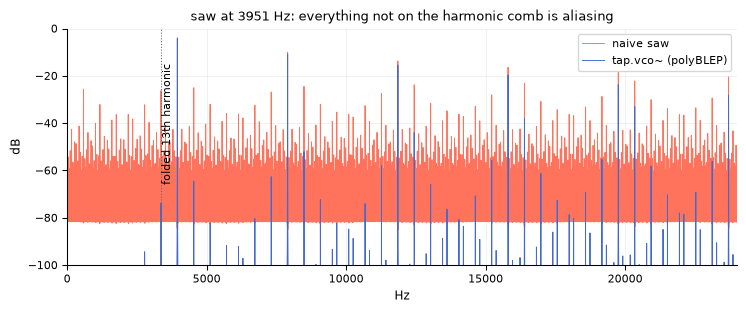

In [3]:
f0 = 3951.07
n = fs
o = tap.Vco(fs, frequency=f0, shape=tap.Vco.SAW)
va = o.process(2 * n)[n:]

t = np.arange(2 * n) / fs
naive = (2.0 * ((f0 * t) % 1.0) - 1.0)[n:]

alias_hz = abs(13 * f0 - fs)          # 13th harmonic folded: ~3364 Hz
fr_v, db_v = spectrum_db(va)
fr_n, db_n = spectrum_db(naive)
suppression = db_at(fr_n, db_n, alias_hz) - db_at(fr_v, db_v, alias_hz)
print(f"alias of the 13th harmonic at {alias_hz:.0f} Hz: "
      f"naive {db_at(fr_n, db_n, alias_hz):.1f} dB, polyBLEP {db_at(fr_v, db_v, alias_hz):.1f} dB "
      f"-> {suppression:.1f} dB suppression")
assert suppression > 30

fig, ax = plt.subplots()
ax.plot(fr_n, db_n, color=PAL[2], lw=0.7, label="naive saw")
ax.plot(fr_v, db_v, color=PAL[0], lw=0.7, label="tap.vco~ (polyBLEP)")
ax.axvline(alias_hz, color="0.4", lw=0.8, ls=":")
ax.annotate("folded 13th harmonic", (alias_hz, -15), fontsize=8, rotation=90, va="top")
ax.set(xlim=(0, 24000), ylim=(-100, 0), xlabel="Hz", ylabel="dB",
       title=f"saw at {f0:.0f} Hz: everything not on the harmonic comb is aliasing")
ax.legend()
plt.show()

## 3. Pulse width is calibrated in percent

A bipolar pulse at duty `d` has mean `2d − 1`: pw 25 % must average −0.5. The BLEP
edges smooth two samples per transition, so the tolerance is small but not zero.

pw 10%: mean -0.800 (want -0.80)
pw 25%: mean -0.500 (want -0.50)
pw 50%: mean +0.000 (want +0.00)


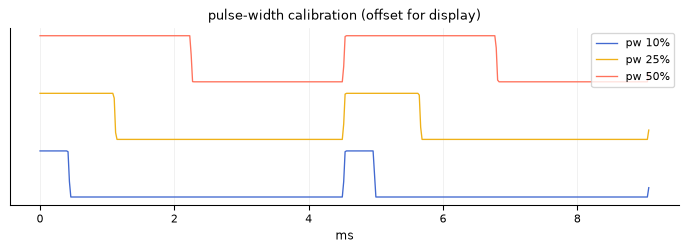

In [4]:
fig, ax = plt.subplots(figsize=(9, 2.4))
for i, pw in enumerate((10, 25, 50)):
    o = tap.Vco(fs, frequency=220, shape=tap.Vco.PULSE, pw=pw)
    y = o.process(fs // 2)[fs // 4:]
    mean = y.mean()
    want = 2 * pw / 100 - 1
    print(f"pw {pw:2d}%: mean {mean:+.3f} (want {want:+.2f})")
    assert abs(mean - want) < 0.03
    cyc = int(2 * fs / 220)
    ax.plot(np.arange(cyc) / fs * 1000, y[:cyc] + 2.5 * i, color=PAL[i], lw=1.0,
            label=f"pw {pw}%")
ax.set(xlabel="ms", yticks=[], title="pulse-width calibration (offset for display)")
ax.legend(loc="upper right")
plt.show()

## 4. The shape morph glides through hybrid waveforms

Shape rides the per-sample ramps, so a slow sweep 0 → 3 passes through sine/tri,
tri/saw, and saw/pulse hybrids without level jumps or dropouts. We morph over two
seconds and watch the spectrogram evolve.

morph 0->3: finite = True, RMS range 0.186..0.996


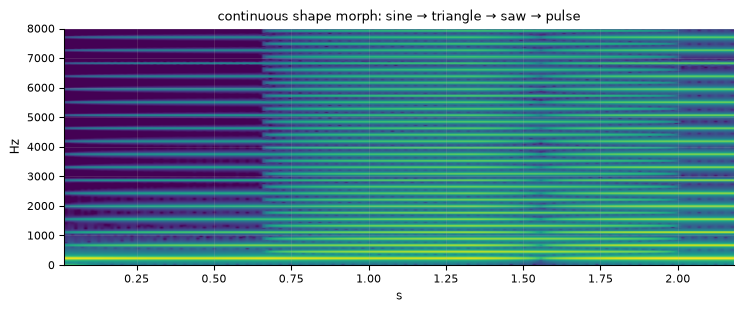

In [5]:
o = tap.Vco(fs, frequency=220, shape=0.0)
o.set(smooth_ms=2000)
o.set(shape=3.0)
y = o.process(int(2.2 * fs))
rms = np.sqrt(np.convolve(y ** 2, np.ones(2048) / 2048, mode="valid"))
print(f"morph 0->3: finite = {np.isfinite(y).all()}, "
      f"RMS range {rms.min():.3f}..{rms.max():.3f}")
assert np.isfinite(y).all()
assert rms.min() > 0.05

fig, ax = plt.subplots()
ax.specgram(y, NFFT=2048, Fs=fs, noverlap=1536, cmap="viridis", vmin=-140)
ax.set(ylim=(0, 8000), xlabel="s", ylabel="Hz",
       title="continuous shape morph: sine → triangle → saw → pulse")
plt.show()

## 5. Hard sync locks the pitch to the master

The sync input resets the phase on every rising zero crossing with sub-sample
accuracy. A slave at 187 Hz synced to a 110 Hz master must be **periodic at 110 Hz**
(that's the whole point of sync timbre): we verify with the autocorrelation period.
Through-zero FM must produce the textbook sidebands and stay bounded at depths far
past the carrier.

synced slave: periodic at 110.1 Hz (master 110 Hz)
TZFM sidebands: -13.7 dB at 500+100 Hz vs -158.3 dB between -> 144.5 dB contrast; max |y| = 1.00


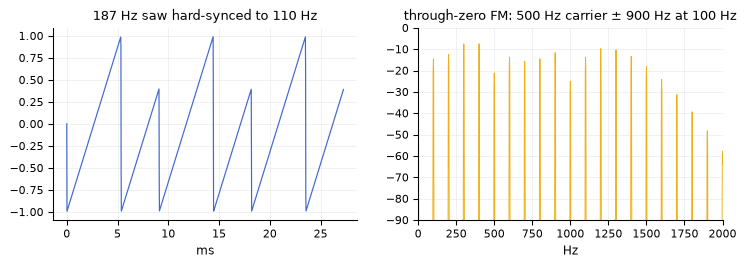

In [6]:
n = fs
t = np.arange(n) / fs
master = np.sin(2 * np.pi * 110 * t)
slave = tap.Vco(fs, frequency=187, shape=tap.Vco.SAW)
y = slave.process(sync=master)[n // 2:]
ac = np.correlate(y - y.mean(), y - y.mean(), "full")[len(y) - 1:]
lag0 = int(fs / 110)
lag = np.argmax(ac[int(0.8 * lag0):int(1.2 * lag0)]) + int(0.8 * lag0)
period_hz = fs / lag
print(f"synced slave: periodic at {period_hz:.1f} Hz (master 110 Hz)")
assert abs(period_hz - 110) / 110 < 0.01

carrier = tap.Vco(fs, frequency=500, shape=tap.Vco.SINE)
fm = 900.0 * np.sin(2 * np.pi * 100 * t)          # depth 900 Hz > carrier: through zero
yfm = carrier.process(fm_hz=fm)[n // 2:]
fr, db = spectrum_db(yfm)
side = db_at(fr, db, 600)
between = db_at(fr, db, 550)
print(f"TZFM sidebands: {side:.1f} dB at 500+100 Hz vs {between:.1f} dB between "
      f"-> {side - between:.1f} dB contrast; max |y| = {np.abs(yfm).max():.2f}")
assert side - between > 20
assert np.abs(yfm).max() < 1.5

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 2.6))
cyc = int(3 * fs / 110)
ax0.plot(np.arange(cyc) / fs * 1000, y[:cyc], color=PAL[0], lw=0.9)
ax0.set(xlabel="ms", title="187 Hz saw hard-synced to 110 Hz")
ax1.plot(fr, db, color=PAL[1], lw=0.7)
ax1.set(xlim=(0, 2000), ylim=(-90, 0), xlabel="Hz",
        title="through-zero FM: 500 Hz carrier ± 900 Hz at 100 Hz")
plt.show()

## 6. Analog drift is deterministic per seed

The drift section (slow random pitch walk) is seeded: the same seed renders
bit-identically (tests and mixes reproduce), different seeds decorrelate (mc.
instances spread).

In [7]:
def render(seed):
    o = tap.Vco(fs, frequency=220, shape=tap.Vco.SAW, drift=20)
    o.seed(seed)
    return o.process(fs // 2)

a, b, c = render(7), render(7), render(8)
print(f"same seed: bit-identical = {np.array_equal(a, b)}; "
      f"different seed: max |diff| = {np.abs(a - c).max():.3f}")
assert np.array_equal(a, b)
assert np.abs(a - c).max() > 1e-3

print("\nAll tap.vco~ claims verified against the shipping kernel.")

same seed: bit-identical = True; different seed: max |diff| = 0.183

All tap.vco~ claims verified against the shipping kernel.
